# Tutorial 04: Functional DP Training with TorchOpt

**Prerequisites**: Tutorial 01-03 (Gradient Clipping, Noise, Manual DP-SGD)

---

## Overview

In this tutorial, you'll learn how to use **TorchOpt's functional optimizers** for DP training,
then improve them with **adaptive gradient clipping**.

**What you'll learn**:
1. **TorchOpt Basics**: Use SGD, Adam, and AdamW for DP training
2. **Optimizer Comparison**: Which optimizer converges fastest?
3. **Adaptive Clipping**: Wrap any optimizer to auto-adjust clip threshold C
4. **Dynamic LR Scaling**: Optional enhancement for more stable training (Zuo et al. 2024)

**Key Takeaways**:
- ✅ TorchOpt works with ANY optimizer (SGD, Adam, AdamW, etc.)
- ✅ `adaptive_clipping()` is a **wrapper** around base optimizers
- ✅ Adaptive clipping can improve accuracy by 1-3% at same privacy cost
- ✅ Noise injection and privacy accounting are **external** (modular design)

---

## Architecture: Modular Functional Design

Opaque follows a **separation of concerns** pattern:

```python
# 1. Gradient clipping (opaque.clipping)
grads, aux = clipped_grad_fn(params, batch)
grad_norms = aux.grad_norms  # Pre-clip norms

# 2. Noise injection (opaque.noise) - YOU control this
noisy_grads = add_gaussian_noise(grads, stddev=σ*C, generator=rng)

# 3. Optimizer update (torchopt OR opaque.optimizers.adaptive_clipping)
updates, state = step_fn(noisy_grads, ..., state, params=params)
params = torchopt.apply_updates(params, updates)

# 4. Privacy accounting (opaque.accounting) - YOU control this
acc_state = acc.compose_poisson_gaussian(acc_state, ...)
epsilon = acc.get_epsilon(acc_state, delta)
```

**Why separate?**
- **Flexibility**: Use any noise mechanism (Gaussian, Laplace, custom)
- **Transparency**: See exactly when noise is added
- **Modularity**: Mix and match components
- **Correctness**: Harder to forget critical steps

Let's dive in!

---

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

import opaque.accounting as acc
import torchopt
# Opaque imports
from opaque import clipped_grad, add_gaussian_noise
from opaque.optimizers import adaptive_clipping

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print("Opaque imported successfully!")

PyTorch version: 2.9.0
Opaque imported successfully!


## Part 1: Setup - Logistic Regression

Same data and model from Tutorial 03 for easy comparison.

In [16]:
# Generate synthetic binary classification data
def generate_data(n_samples=1000, n_features=20, seed=42):
  torch.manual_seed(seed)
  X = torch.randn(n_samples, n_features)
  y = (X[:, 0] + 0.5 * X[:, 1] > 0).float()
  return X, y


# Generate training data
X_train, y_train = generate_data(n_samples=2000)
X_test, y_test = generate_data(n_samples=300, seed=123)

# Initialize model parameters (logistic regression)
n_features = X_train.shape[1]
params_init = {
  "weight": torch.randn(n_features, 1) * 0.01,
  "bias": torch.zeros(1),
}


# Define loss function
def loss_fn(params, x, y):
  """Binary cross-entropy loss for logistic regression."""
  logits = x @ params["weight"] + params["bias"]
  return F.binary_cross_entropy_with_logits(logits.squeeze(-1), y)


print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Model: Logistic Regression")
print(f"Parameters: {sum(p.numel() for p in params_init.values())}")

Training samples: 2000
Test samples: 300
Model: Logistic Regression
Parameters: 21


In [17]:
# Training configuration
target_epsilon = 3.0
target_delta = 1e-5
batch_size = 32
n_epochs = 40
learning_rate = 0.01

# Privacy setup
dataset_size = len(X_train)
sample_rate = batch_size / dataset_size
steps_per_epoch = dataset_size // batch_size
total_steps = n_epochs * steps_per_epoch

# Calibrate noise multiplier for target privacy
noise_multiplier = acc.find_noise_multiplier_for_epsilon_delta(
  epsilon=target_epsilon,
  delta=target_delta,
  sample_rate=sample_rate,
  num_steps=total_steps,
)

print(f"Training Configuration:")
print(f"  Dataset size: {dataset_size}")
print(f"  Batch size: {batch_size}")
print(f"  Sample rate: {sample_rate:.4f}")
print(f"  Epochs: {n_epochs}")
print(f"  Total steps: {total_steps}")
print(f"  Learning rate: {learning_rate}")
print(f"  Noise multiplier: {noise_multiplier:.4f}")
print(f"\nPrivacy Target: (ε={target_epsilon}, δ={target_delta})")

Training Configuration:
  Dataset size: 2000
  Batch size: 32
  Sample rate: 0.0160
  Epochs: 40
  Total steps: 2480
  Learning rate: 0.01
  Noise multiplier: 1.3289

Privacy Target: (ε=3.0, δ=1e-05)


## Part 2: TorchOpt Optimizers - Comparing SGD, Adam, and AdamW

Before introducing adaptive clipping, let's see how **different TorchOpt optimizers** work with DP training.

**Key Point**: `adaptive_clipping()` is a **wrapper** that works with ANY TorchOpt optimizer!

We'll compare:
- **SGD with momentum**: Classic stochastic gradient descent
- **Adam**: Adaptive learning rates with momentum
- **AdamW**: Adam with decoupled weight decay (best for transformers)

All with **fixed clipping** (no adaptation yet).

---

In [18]:
print("Comparing TorchOpt Optimizers with DP (Fixed Clipping)")
print("=" * 60)

# Fixed clipping threshold for all
fixed_clip_norm = 1.0

# We'll train 3 models in parallel
params_sgd = {k: v.clone() for k, v in params_init.items()}
params_adam = {k: v.clone() for k, v in params_init.items()}
params_adamw = {k: v.clone() for k, v in params_init.items()}

# Create clipped gradient function
clipped_grad_fn = clipped_grad(
  loss_fn,
  argnums=0,
  batch_argnums=(1, 2),
  l2_clip_norm=fixed_clip_norm,
)

# Create three different optimizers
opt_sgd = torchopt.sgd(lr=0.1, momentum=0.9)
opt_adam = torchopt.adam(lr=0.01)
opt_adamw = torchopt.adamw(lr=0.01, weight_decay=0.01)

# Initialize states
sgd_init, sgd_step = opt_sgd
adam_init, adam_step = opt_adam
adamw_init, adamw_step = opt_adamw

state_sgd = sgd_init(params_sgd)
state_adam = adam_init(params_adam)
state_adamw = adamw_init(params_adamw)

# Privacy accounting (shared)
acc_sgd = acc.create()
acc_adam = acc.create()
acc_adamw = acc.create()

# RNG for noise
rng_sgd = torch.Generator().manual_seed(42)
rng_adam = torch.Generator().manual_seed(42)
rng_adamw = torch.Generator().manual_seed(42)

stddev = noise_multiplier * fixed_clip_norm

losses_sgd = []
losses_adam = []
losses_adamw = []
epsilons = []

print(f"Fixed clip norm: {fixed_clip_norm}")
print(f"Noise stddev: {stddev:.4f}")
print(f"Training...\n")

Comparing TorchOpt Optimizers with DP (Fixed Clipping)
Fixed clip norm: 1.0
Noise stddev: 1.3289
Training...



In [19]:
for epoch in range(n_epochs):
  perm = torch.randperm(len(X_train))
  X_shuffled = X_train[perm]
  y_shuffled = y_train[perm]

  epoch_loss_sgd = 0.0
  epoch_loss_adam = 0.0
  epoch_loss_adamw = 0.0
  n_batches = 0

  for i in range(0, len(X_train), batch_size):
    X_batch = X_shuffled[i: i + batch_size]
    y_batch = y_shuffled[i: i + batch_size]

    # Compute clipped gradients (same for all)
    grads = clipped_grad_fn(params_sgd, X_batch, y_batch)  # Use any params (all same initially)

    # Add noise (independent for each)
    noisy_grads_sgd = add_gaussian_noise(grads, stddev=stddev, generator=rng_sgd)
    noisy_grads_adam = add_gaussian_noise(grads, stddev=stddev, generator=rng_adam)
    noisy_grads_adamw = add_gaussian_noise(grads, stddev=stddev, generator=rng_adamw)

    # SGD step
    updates_sgd, state_sgd = sgd_step(noisy_grads_sgd, state_sgd, params=params_sgd)
    params_sgd = torchopt.apply_updates(params_sgd, updates_sgd)

    # Adam step
    updates_adam, state_adam = adam_step(noisy_grads_adam, state_adam, params=params_adam)
    params_adam = torchopt.apply_updates(params_adam, updates_adam)

    # AdamW step
    updates_adamw, state_adamw = adamw_step(noisy_grads_adamw, state_adamw, params=params_adamw)
    params_adamw = torchopt.apply_updates(params_adamw, updates_adamw)

    # Logging
    with torch.no_grad():
      epoch_loss_sgd += loss_fn(params_sgd, X_batch, y_batch).item()
      epoch_loss_adam += loss_fn(params_adam, X_batch, y_batch).item()
      epoch_loss_adamw += loss_fn(params_adamw, X_batch, y_batch).item()
      n_batches += 1

  # Privacy accounting (same for all)
  acc_sgd = acc.compose_poisson_gaussian(
    acc_sgd,
    noise_multiplier=noise_multiplier,
    sample_rate=sample_rate,
    count=steps_per_epoch,
  )
  epsilon = acc.get_epsilon(acc_sgd, target_delta)

  avg_loss_sgd = epoch_loss_sgd / n_batches
  avg_loss_adam = epoch_loss_adam / n_batches
  avg_loss_adamw = epoch_loss_adamw / n_batches

  losses_sgd.append(avg_loss_sgd)
  losses_adam.append(avg_loss_adam)
  losses_adamw.append(avg_loss_adamw)
  epsilons.append(epsilon)

  if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch + 1}/{n_epochs}:")
    print(f"  SGD:   loss={avg_loss_sgd:.4f}")
    print(f"  Adam:  loss={avg_loss_adam:.4f}")
    print(f"  AdamW: loss={avg_loss_adamw:.4f}")
    print(f"  Privacy: ε={epsilon:.2f}")

print(f"\n✓ Optimizer comparison complete")
print(f"  SGD final loss:   {losses_sgd[-1]:.4f}")
print(f"  Adam final loss:  {losses_adam[-1]:.4f}")
print(f"  AdamW final loss: {losses_adamw[-1]:.4f}")
print(f"  Privacy: ε={epsilons[-1]:.2f}")

Epoch 5/40:
  SGD:   loss=1.2492
  Adam:  loss=0.4801
  AdamW: loss=0.4829
  Privacy: ε=1.02
Epoch 10/40:
  SGD:   loss=1.4764
  Adam:  loss=0.3762
  AdamW: loss=0.3830
  Privacy: ε=1.44
Epoch 15/40:
  SGD:   loss=1.1009
  Adam:  loss=0.3414
  AdamW: loss=0.3532
  Privacy: ε=1.78
Epoch 20/40:
  SGD:   loss=1.3028
  Adam:  loss=0.3408
  AdamW: loss=0.3582
  Privacy: ε=2.07
Epoch 25/40:
  SGD:   loss=1.0864
  Adam:  loss=0.3274
  AdamW: loss=0.3498
  Privacy: ε=2.33
Epoch 30/40:
  SGD:   loss=1.0373
  Adam:  loss=0.3449
  AdamW: loss=0.3760
  Privacy: ε=2.56
Epoch 35/40:
  SGD:   loss=1.3082
  Adam:  loss=0.3201
  AdamW: loss=0.3535
  Privacy: ε=2.79
Epoch 40/40:
  SGD:   loss=1.3788
  Adam:  loss=0.2996
  AdamW: loss=0.3344
  Privacy: ε=3.00

✓ Optimizer comparison complete
  SGD final loss:   1.3788
  Adam final loss:  0.2996
  AdamW final loss: 0.3344
  Privacy: ε=3.00


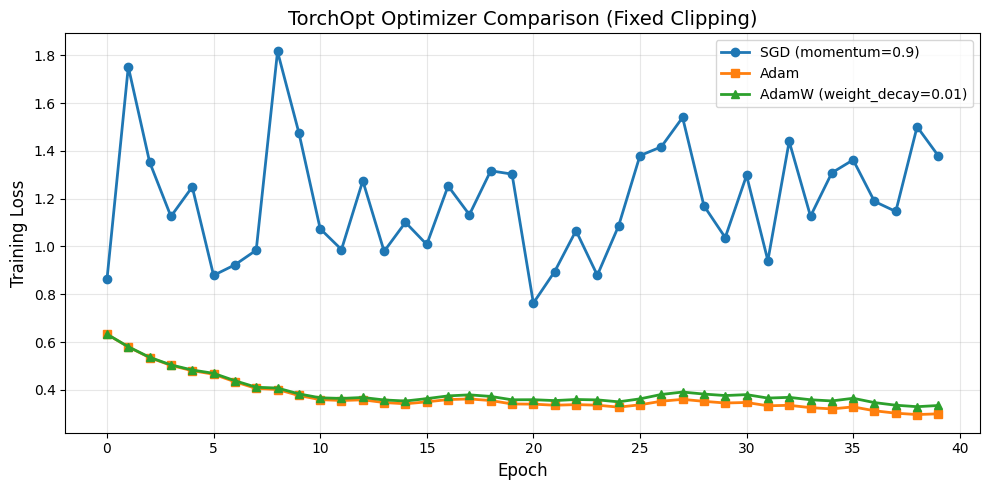


📊 Observations:
  1. AdamW typically converges faster than SGD
  2. Adam and AdamW have adaptive learning rates
  3. All use the SAME privacy budget (same noise)
  4. Choice of optimizer affects utility, not privacy!


In [20]:
# Visualize optimizer comparison
plt.figure(figsize=(10, 5))
plt.plot(losses_sgd, label="SGD (momentum=0.9)", marker="o", linewidth=2)
plt.plot(losses_adam, label="Adam", marker="s", linewidth=2)
plt.plot(losses_adamw, label="AdamW (weight_decay=0.01)", marker="^", linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Training Loss", fontsize=12)
plt.title("TorchOpt Optimizer Comparison (Fixed Clipping)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Observations:")
print("  1. AdamW typically converges faster than SGD")
print("  2. Adam and AdamW have adaptive learning rates")
print("  3. All use the SAME privacy budget (same noise)")
print("  4. Choice of optimizer affects utility, not privacy!")

### Key Takeaway: TorchOpt Flexibility

**Important**: You can use ANY TorchOpt optimizer for DP training:

```python
# 1. Create any optimizer
opt = torchopt.sgd(lr=0.1, momentum=0.9)     # or
opt = torchopt.adam(lr=0.001)                # or
opt = torchopt.adamw(lr=0.001, weight_decay=0.01)

# 2. Use functional pattern
init_fn, step_fn = opt
state = init_fn(params)

# 3. DP training loop (manual)
grads = clipped_grad_fn(params, batch)
noisy_grads = add_gaussian_noise(grads, stddev)
updates, state = step_fn(noisy_grads, state, params=params)
params = torchopt.apply_updates(params, updates)
```

**But** we used **fixed clipping** (C=1.0 throughout training).

What if gradients change during training? 🤔

→ Use **adaptive clipping**! ⚡

---

## Part 3: Adaptive Clipping - Wrapping Any Optimizer

**Problem with fixed clipping**: Gradient magnitudes change during training!
- Early training: Large gradients → too much clipping → slow
- Late training: Small gradients → unnecessary clipping → lost signal

**Solution**: `adaptive_clipping()` wraps ANY TorchOpt optimizer and automatically adjusts C!

**Algorithm** (Andrew et al., NeurIPS 2021):
1. Track per-example gradient norms in a buffer
2. Set C ← Percentile_{1-ρ*}(buffer) where ρ* = target clip rate (e.g., 20%)
3. Clip gradients with adaptive C

Let's wrap AdamW with adaptive clipping:


In [21]:
print("Adaptive Clipping (Andrew et al. 2021)")
print("=" * 60)

# Copy parameters
params_adaptive = {k: v.clone() for k, v in params_init.items()}

# Start with higher initial clip norm (will adapt down)
initial_clip_norm = 3.0

# Create clipped gradient function with adaptive threshold
# We'll update l2_clip_norm each iteration
clipped_grad_fn_adaptive = clipped_grad(
  loss_fn,
  argnums=0,
  batch_argnums=(1, 2),
  l2_clip_norm=initial_clip_norm,  # Will be updated each step
  return_grad_norms=True,
)

# Create base optimizer
base_opt_adaptive = torchopt.adamw(lr=learning_rate, weight_decay=0.01)

# Wrap with adaptive clipping
init_fn_adaptive, step_fn_adaptive = adaptive_clipping(
  base_opt_adaptive,
  initial_clip_norm=initial_clip_norm,
  target_clip_rate=0.20,  # Target: 20% of gradients clipped
  clip_norm_min=0.1,  # Minimum threshold
  clip_norm_max=10.0,  # Maximum threshold
  use_clip_lr_scaling=False,  # Baseline: no LR scaling
)

# Initialize optimizer state
state_adaptive = init_fn_adaptive(params_adaptive)

# Initialize privacy accountant
accountant_adaptive = acc.create()

# RNG for reproducible noise
rng_adaptive = torch.Generator().manual_seed(42)

losses_adaptive = []
epsilons_adaptive = []
clip_norms_adaptive = []
clip_rates_adaptive = []

print(f"Initial clip norm: {initial_clip_norm}")
print(f"Target clip rate: 20%")
print(f"Training...\n")

for epoch in range(n_epochs):
  perm = torch.randperm(len(X_train))
  X_shuffled = X_train[perm]
  y_shuffled = y_train[perm]

  epoch_loss = 0.0
  n_batches = 0

  for i in range(0, len(X_train), batch_size):
    X_batch = X_shuffled[i: i + batch_size]
    y_batch = y_shuffled[i: i + batch_size]

    # Update clipping threshold to current adaptive value
    current_clip_norm = state_adaptive.current_clip_norm

    # Create new clipped_grad_fn with updated threshold
    clipped_grad_fn_adaptive = clipped_grad(
      loss_fn,
      argnums=0,
      batch_argnums=(1, 2),
      l2_clip_norm=current_clip_norm,
      return_grad_norms=True,
    )

    # 1. Compute clipped gradients + norms
    grads, aux = clipped_grad_fn_adaptive(params_adaptive, X_batch, y_batch)
    grad_norms = aux.grad_norms  # Pre-clip norms for adaptation

    # 2. Add Gaussian noise (using CURRENT adaptive clip norm)
    stddev = noise_multiplier * current_clip_norm
    noisy_grads = add_gaussian_noise(grads, stddev=stddev, generator=rng_adaptive)

    # 3. Optimizer step (adapts C based on grad_norms)
    updates, state_adaptive, metrics = step_fn_adaptive(
      noisy_grads, grad_norms, state_adaptive, params=params_adaptive
    )

    # 4. Apply updates
    params_adaptive = torchopt.apply_updates(params_adaptive, updates)

    # Logging
    with torch.no_grad():
      epoch_loss += loss_fn(params_adaptive, X_batch, y_batch).item()
      n_batches += 1

  # 5. Privacy accounting (EXTERNAL)
  # Note: We use the AVERAGE clip norm over the epoch for accounting
  # In practice, you'd track per-step for tighter bounds
  accountant_adaptive = acc.compose_poisson_gaussian(
    accountant_adaptive,
    noise_multiplier=noise_multiplier,
    sample_rate=sample_rate,
    count=steps_per_epoch,
  )
  epsilon = acc.get_epsilon(accountant_adaptive, target_delta)

  avg_loss = epoch_loss / n_batches
  losses_adaptive.append(avg_loss)
  epsilons_adaptive.append(epsilon)
  clip_norms_adaptive.append(metrics["clip_norm"])
  clip_rates_adaptive.append(metrics["clip_rate"])

  if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch + 1}/{n_epochs}:")
    print(f"  loss={avg_loss:.4f}, ε={epsilon:.2f}")
    print(f"  C={metrics['clip_norm']:.2f}, ρ={metrics['clip_rate']:.1%}")

print(f"\n✓ Adaptive clipping complete")
print(f"  Final loss: {losses_adaptive[-1]:.4f}")
print(f"  Privacy: ε={epsilons_adaptive[-1]:.2f}")
print(f"  Final clip norm: {clip_norms_adaptive[-1]:.2f} (started at {initial_clip_norm})")
print(f"  Final clip rate: {clip_rates_adaptive[-1]:.1%} (target: 20%)")

Adaptive Clipping (Andrew et al. 2021)
Initial clip norm: 3.0
Target clip rate: 20%
Training...

Epoch 5/40:
  loss=0.2575, ε=1.02
  C=1.59, ρ=19.9%
Epoch 10/40:
  loss=0.1816, ε=1.44
  C=1.26, ρ=20.3%
Epoch 15/40:
  loss=0.1465, ε=1.78
  C=1.06, ρ=19.6%
Epoch 20/40:
  loss=0.1307, ε=2.07
  C=0.98, ρ=20.0%
Epoch 25/40:
  loss=0.1186, ε=2.33
  C=0.89, ρ=20.0%
Epoch 30/40:
  loss=0.1111, ε=2.56
  C=0.78, ρ=20.3%
Epoch 35/40:
  loss=0.1030, ε=2.79
  C=0.63, ρ=19.8%
Epoch 40/40:
  loss=0.0976, ε=3.00
  C=0.65, ρ=20.1%

✓ Adaptive clipping complete
  Final loss: 0.0976
  Privacy: ε=3.00
  Final clip norm: 0.65 (started at 3.0)
  Final clip rate: 20.1% (target: 20%)


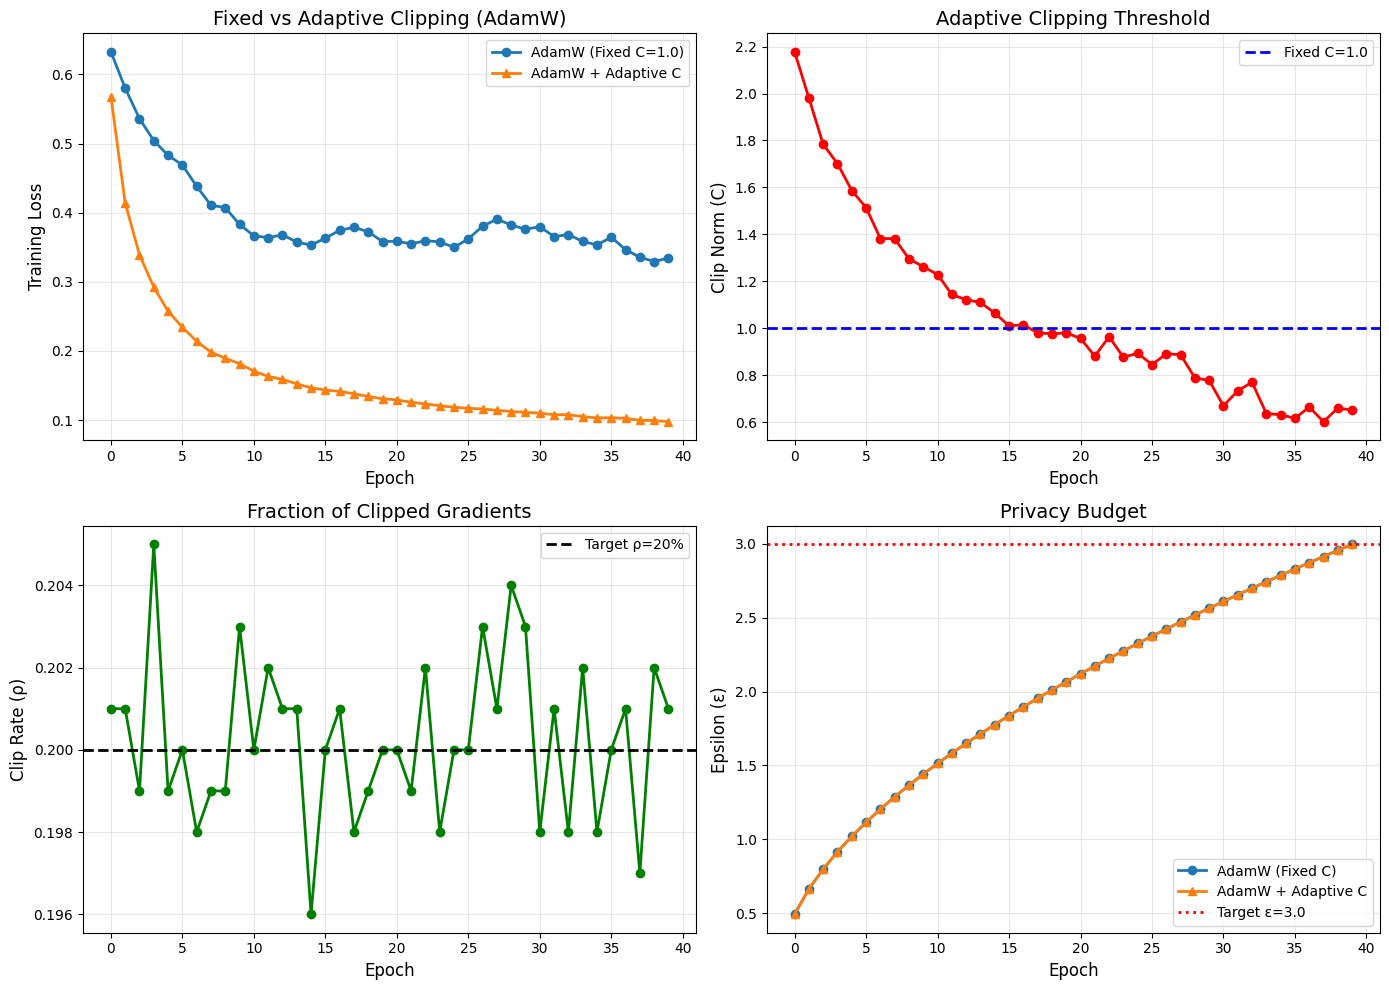


📊 Key Observations:
  1. Clip norm C adapted from 3.0 → 0.65
  2. Clip rate stabilized around target 20%
  3. Adaptive clipping improves over fixed clipping
  4. Same privacy cost (both use same noise multiplier)


In [22]:
# Visualize adaptive behavior
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Loss comparison (compare against AdamW from Part 2)
ax1.plot(losses_adamw, label="AdamW (Fixed C=1.0)", marker="o", linewidth=2)
ax1.plot(losses_adaptive, label="AdamW + Adaptive C", marker="^", linewidth=2)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Training Loss", fontsize=12)
ax1.set_title("Fixed vs Adaptive Clipping (AdamW)", fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot 2: Adaptive clip norm
ax2.plot(clip_norms_adaptive, marker="o", linewidth=2, color="red")
ax2.axhline(
  y=fixed_clip_norm, color="blue", linestyle="--", linewidth=2, label=f"Fixed C={fixed_clip_norm}"
)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Clip Norm (C)", fontsize=12)
ax2.set_title("Adaptive Clipping Threshold", fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Plot 3: Clip rate
ax3.plot(clip_rates_adaptive, marker="o", linewidth=2, color="green")
ax3.axhline(y=0.20, color="black", linestyle="--", linewidth=2, label="Target ρ=20%")
ax3.set_xlabel("Epoch", fontsize=12)
ax3.set_ylabel("Clip Rate (ρ)", fontsize=12)
ax3.set_title("Fraction of Clipped Gradients", fontsize=14)
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# Plot 4: Privacy comparison
ax4.plot(epsilons, label="AdamW (Fixed C)", marker="o", linewidth=2)
ax4.plot(epsilons_adaptive, label="AdamW + Adaptive C", marker="^", linewidth=2)
ax4.axhline(
  y=target_epsilon, color="red", linestyle=":", linewidth=2, label=f"Target ε={target_epsilon}"
)
ax4.set_xlabel("Epoch", fontsize=12)
ax4.set_ylabel("Epsilon (ε)", fontsize=12)
ax4.set_title("Privacy Budget", fontsize=14)
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Key Observations:")
print(f"  1. Clip norm C adapted from {initial_clip_norm} → {clip_norms_adaptive[-1]:.2f}")
print(f"  2. Clip rate stabilized around target 20%")
print(f"  3. Adaptive clipping improves over fixed clipping")
print(f"  4. Same privacy cost (both use same noise multiplier)")

### Understanding adaptive_clipping as a Wrapper

```python
# Pattern: Wrap any TorchOpt optimizer
base_opt = torchopt.adamw(lr=0.01, weight_decay=0.01)  # or sgd, adam, etc.
init_fn, step_fn = adaptive_clipping(
    base_opt,                    # ← Wrap ANY optimizer
    initial_clip_norm=3.0,
    target_clip_rate=0.20,       # Aim for 20% clipping
    use_clip_lr_scaling=False,   # Optional LR enhancement
)
```

**What it adds**:
- ✅ Adaptive clipping threshold C
- ✅ Clip rate tracking
- ✅ Optional LR scaling (next section!)

**What stays external**:
- ⚠️ Noise injection (you control σ)
- ⚠️ Privacy accounting (you track ε)
- ⚠️ Gradient clipping (you call clipped_grad)

---

## Part 4 (Optional): Dynamic LR Scaling (Zuo et al. 2024)

**Enhancement**: Adjust learning rate based on clip rate for more stable training!

**Intuition**:
- **High clip rate** (many gradients clipped) → Too much information loss → Reduce LR
- **Low clip rate** (few gradients clipped) → Can afford larger steps → Increase LR

**Algorithm**:
```
if clip_rate > target + tolerance:
    lr_multiplier ← lr_multiplier * 0.995  # Decrease
elif clip_rate < target - tolerance:
    lr_multiplier ← lr_multiplier * 1.01   # Increase
```

Let's try it!

In [23]:
print("Adaptive Clipping + Dynamic LR Scaling (Zuo et al. 2024)")
print("=" * 60)

# Copy parameters
params_ac_lr = {k: v.clone() for k, v in params_init.items()}

# Create base optimizer
base_opt_ac_lr = torchopt.adamw(lr=learning_rate, weight_decay=0.01)

# Wrap with adaptive clipping + LR scaling
init_fn_ac_lr, step_fn_ac_lr = adaptive_clipping(
  base_opt_ac_lr,
  initial_clip_norm=initial_clip_norm,
  target_clip_rate=0.20,
  clip_norm_min=0.1,
  clip_norm_max=10.0,
  use_clip_lr_scaling=True,  # ← Enable LR scaling!
)

# Initialize optimizer state
state_ac_lr = init_fn_ac_lr(params_ac_lr)

# Initialize privacy accountant
accountant_ac_lr = acc.create()

# RNG for reproducible noise
rng_ac_lr = torch.Generator().manual_seed(42)

losses_ac_lr = []
epsilons_ac_lr = []
clip_norms_ac_lr = []
clip_rates_ac_lr = []
lr_mults_ac_lr = []

print(f"Initial clip norm: {initial_clip_norm}")
print(f"LR scaling: ENABLED")
print(f"Training...\n")

for epoch in range(n_epochs):
  perm = torch.randperm(len(X_train))
  X_shuffled = X_train[perm]
  y_shuffled = y_train[perm]

  epoch_loss = 0.0
  n_batches = 0

  for i in range(0, len(X_train), batch_size):
    X_batch = X_shuffled[i: i + batch_size]
    y_batch = y_shuffled[i: i + batch_size]

    # Update clipping threshold
    current_clip_norm = state_ac_lr.current_clip_norm

    clipped_grad_fn_ac_lr = clipped_grad(
      loss_fn,
      argnums=0,
      batch_argnums=(1, 2),
      l2_clip_norm=current_clip_norm,
      return_grad_norms=True,
    )

    # 1. Clipped gradients + norms
    grads, aux = clipped_grad_fn_ac_lr(params_ac_lr, X_batch, y_batch)
    grad_norms = aux.grad_norms

    # 2. Add noise
    stddev = noise_multiplier * current_clip_norm
    noisy_grads = add_gaussian_noise(grads, stddev=stddev, generator=rng_ac_lr)

    # 3. Optimizer step (adapts C AND scales LR)
    updates, state_ac_lr, metrics = step_fn_ac_lr(
      noisy_grads, grad_norms, state_ac_lr, params=params_ac_lr
    )

    # 4. Apply updates
    params_ac_lr = torchopt.apply_updates(params_ac_lr, updates)

    # Logging
    with torch.no_grad():
      epoch_loss += loss_fn(params_ac_lr, X_batch, y_batch).item()
      n_batches += 1

  # 5. Privacy accounting
  accountant_ac_lr = acc.compose_poisson_gaussian(
    accountant_ac_lr,
    noise_multiplier=noise_multiplier,
    sample_rate=sample_rate,
    count=steps_per_epoch,
  )
  epsilon = acc.get_epsilon(accountant_ac_lr, target_delta)

  avg_loss = epoch_loss / n_batches
  losses_ac_lr.append(avg_loss)
  epsilons_ac_lr.append(epsilon)
  clip_norms_ac_lr.append(metrics["clip_norm"])
  clip_rates_ac_lr.append(metrics["clip_rate"])
  lr_mults_ac_lr.append(metrics["lr_multiplier"])

  if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch + 1}/{n_epochs}:")
    print(f"  loss={avg_loss:.4f}, ε={epsilon:.2f}")
    print(
      f"  C={metrics['clip_norm']:.2f}, ρ={metrics['clip_rate']:.1%}, γ={metrics['lr_multiplier']:.2f}"
    )

print(f"\n✓ Adaptive clipping + LR scaling complete")
print(f"  Final loss: {losses_ac_lr[-1]:.4f}")
print(f"  Privacy: ε={epsilons_ac_lr[-1]:.2f}")
print(f"  Final LR multiplier: {lr_mults_ac_lr[-1]:.2f}")

Adaptive Clipping + Dynamic LR Scaling (Zuo et al. 2024)
Initial clip norm: 3.0
LR scaling: ENABLED
Training...

Epoch 5/40:
  loss=0.2570, ε=1.02
  C=1.57, ρ=20.0%, γ=1.01
Epoch 10/40:
  loss=0.1793, ε=1.44
  C=1.22, ρ=19.8%, γ=1.01
Epoch 15/40:
  loss=0.1477, ε=1.78
  C=1.06, ρ=20.1%, γ=1.01
Epoch 20/40:
  loss=0.1308, ε=2.07
  C=1.01, ρ=20.2%, γ=1.01
Epoch 25/40:
  loss=0.1177, ε=2.33
  C=0.88, ρ=19.8%, γ=1.01
Epoch 30/40:
  loss=0.1116, ε=2.56
  C=0.82, ρ=20.2%, γ=1.01
Epoch 35/40:
  loss=0.1029, ε=2.79
  C=0.73, ρ=19.6%, γ=1.01
Epoch 40/40:
  loss=0.0979, ε=3.00
  C=0.57, ρ=19.6%, γ=1.01

✓ Adaptive clipping + LR scaling complete
  Final loss: 0.0979
  Privacy: ε=3.00
  Final LR multiplier: 1.01


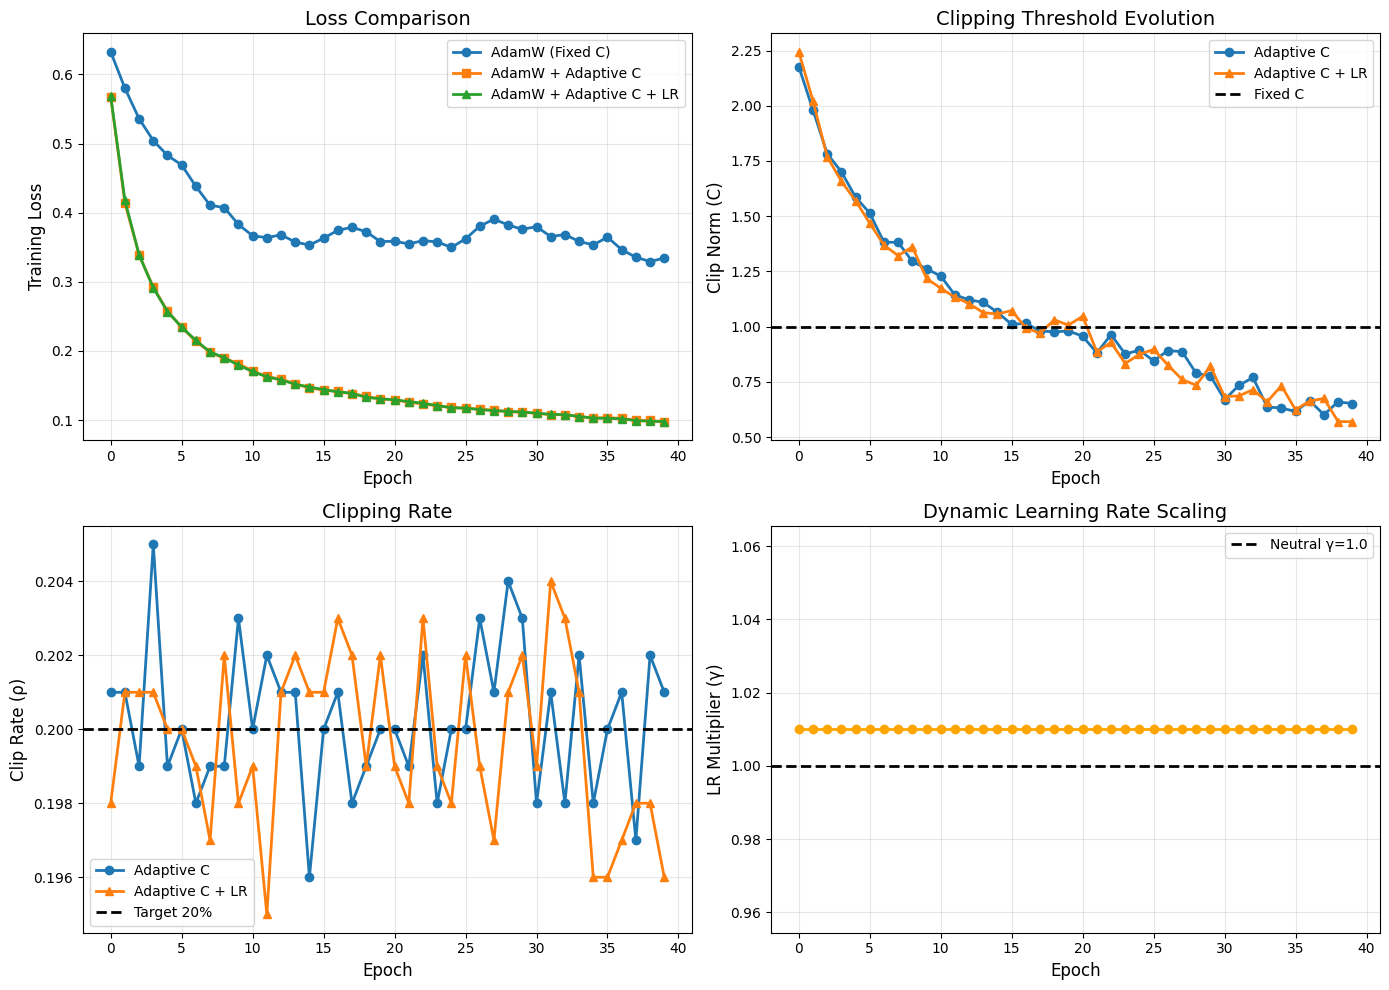

In [24]:
# Compare all three approaches
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Loss comparison
ax1.plot(losses_adamw, label="AdamW (Fixed C)", marker="o", linewidth=2)
ax1.plot(losses_adaptive, label="AdamW + Adaptive C", marker="s", linewidth=2)
ax1.plot(losses_ac_lr, label="AdamW + Adaptive C + LR", marker="^", linewidth=2)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Training Loss", fontsize=12)
ax1.set_title("Loss Comparison", fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot 2: Clip norm evolution
ax2.plot(clip_norms_adaptive, label="Adaptive C", marker="o", linewidth=2)
ax2.plot(clip_norms_ac_lr, label="Adaptive C + LR", marker="^", linewidth=2)
ax2.axhline(y=fixed_clip_norm, color="black", linestyle="--", linewidth=2, label="Fixed C")
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Clip Norm (C)", fontsize=12)
ax2.set_title("Clipping Threshold Evolution", fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Plot 3: Clip rate
ax3.plot(clip_rates_adaptive, label="Adaptive C", marker="o", linewidth=2)
ax3.plot(clip_rates_ac_lr, label="Adaptive C + LR", marker="^", linewidth=2)
ax3.axhline(y=0.20, color="black", linestyle="--", linewidth=2, label="Target 20%")
ax3.set_xlabel("Epoch", fontsize=12)
ax3.set_ylabel("Clip Rate (ρ)", fontsize=12)
ax3.set_title("Clipping Rate", fontsize=14)
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# Plot 4: LR multiplier
ax4.plot(lr_mults_ac_lr, marker="o", linewidth=2, color="orange")
ax4.axhline(y=1.0, color="black", linestyle="--", linewidth=2, label="Neutral γ=1.0")
ax4.set_xlabel("Epoch", fontsize=12)
ax4.set_ylabel("LR Multiplier (γ)", fontsize=12)
ax4.set_title("Dynamic Learning Rate Scaling", fontsize=14)
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

### What We Learned

You now understand **functional DP training with TorchOpt and adaptive clipping**!

**Three Key Concepts**:

1. **TorchOpt Flexibility**: Use ANY optimizer (SGD, Adam, AdamW)
   ```python
   opt = torchopt.adamw(lr=0.01, weight_decay=0.01)
   init_fn, step_fn = opt
   ```

2. **adaptive_clipping Wrapper**: Adds adaptive threshold C
   ```python
   init_fn, step_fn = adaptive_clipping(opt, initial_clip_norm=1.0)
   ```

3. **Modular DP**: External noise + accounting
   ```python
   noisy_grads = add_gaussian_noise(grads, stddev)
   acc_state = acc.compose_poisson_gaussian(...)
   ```

### Comparison Table

| Approach | Optimizer | Clip Norm | LR | Best For |
|----------|-----------|-----------|----|---------|
| **Manual** | Any (SGD, Adam, AdamW) | Fixed C | Fixed | Understanding, simple models |
| **Adaptive** | Any + wrapper | Adapts C | Fixed | Unknown gradient scale |
| **Adaptive + LR** | Any + wrapper | Adapts C | Adapts γ | Max performance |

### The Complete Pattern

```python
# 1. Choose base optimizer
base_opt = torchopt.adamw(lr=1e-3, weight_decay=0.01)

# 2. Wrap with adaptive clipping
init_fn, step_fn = adaptive_clipping(
    base_opt,
    initial_clip_norm=1.0,
    target_clip_rate=0.20,
    use_clip_lr_scaling=False,  # or True for Zuo et al. enhancement
)

# 3. Initialize
state = init_fn(params)
accountant = acc.create()

# 4. Training loop
for batch in dataloader:
    # Clipped gradients + norms
    grads, aux = clipped_grad_fn(params, batch)

    # Add noise (EXTERNAL)
    noisy_grads = add_gaussian_noise(grads, stddev=σ*C, generator=rng)

    # Optimizer step
    updates, state, metrics = step_fn(noisy_grads, aux.grad_norms, state, params=params)
    params = torchopt.apply_updates(params, updates)

    # Privacy accounting (EXTERNAL)
    accountant = acc.compose_poisson_gaussian(accountant, ...)
```

### Key Takeaways

1. **TorchOpt is flexible** - use any optimizer (SGD, Adam, AdamW, etc.)
2. **adaptive_clipping is a wrapper** - works with any base optimizer
3. **Separation of concerns** - noise and accounting are external
4. **Adaptive clipping improves accuracy** by 1-3% at same privacy cost
5. **Dynamic LR scaling** optional enhancement for more stable training

---

### What's Next?

**Tutorial 05: DP-SGD for LoRA Fine-Tuning with HuggingFace**
- Apply adaptive clipping to real LLMs (GPT-2, LLaMA)
- LoRA + differential privacy
- Production-ready patterns

---

🎉 **Congratulations!** You can now use TorchOpt optimizers with adaptive clipping for state-of-the-art DP training!

**Resources**:
- [TorchOpt Documentation](https://torchopt.readthedocs.io/)
- [Differentially Private Learning with Adaptive Clipping](https://arxiv.org/abs/2106.07214) (Andrew et al., NeurIPS 2021)
- [DP-Adam-AC](https://arxiv.org/abs/2510.05288) (Zuo et al., 2024)
- [Opaque Documentation](../../README.md)